In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Define dataset size and fraud rate
total_records = 2000000
fraud_percentage = 0.05
num_fraud = int(total_records * fraud_percentage)

# Generate IDs
ids = np.arange(1, total_records + 1)

# Generate synthetic data
transaction_count = np.random.poisson(20, total_records)
country_risk = np.random.randint(1, 11, total_records)
transaction_type = np.random.choice(['Deposit', 'Withdrawal', 'Transfer'], total_records)
customer_age = np.random.randint(18, 70, total_records)
customer_account_tenure = np.round(np.random.exponential(3, total_records), 1)
customer_type = np.random.choice(['Individual', 'Corporate', 'NGO', 'Trust'], total_records)
account_status = np.random.choice(['Active', 'Dormant', 'Closed'], total_records)
kyc_compliance = np.random.choice(['Complete', 'Incomplete', 'Partial'], total_records, p=[0.8, 0.1, 0.1])
industry_risk = np.random.choice(['Low', 'Medium', 'High'], total_records, p=[0.7, 0.2, 0.1])

# Define occupation-based income in INR
occupation = np.random.choice([
    'Unemployed', 'Business Owner', 'Real Estate Agent', 'Banker', 'Retail Worker',
    'Lawyer', 'Doctor', 'Engineer', 'Consultant', 'Student'], total_records)

income = np.round(np.where(
    np.isin(occupation, ['Unemployed', 'Student']), np.random.uniform(1000, 7000, total_records),
    np.where(
        np.isin(occupation, ['Retail Worker', 'Consultant']), np.random.uniform(15000, 30000, total_records),
        np.where(
            np.isin(occupation, ['Engineer', 'Lawyer', 'Doctor']), np.random.uniform(40000, 80000, total_records),
            np.where(
                occupation == 'Banker', np.random.uniform(50000, 100000, total_records),
                np.random.uniform(80000, 250000, total_records)  # higher income for business owners, real estate agents
            )
        )
    )
), 2)

# Generate expenditure (Transaction_Amount) based on income levels
transaction_amount = np.round(np.where(
    np.isin(occupation, ['Unemployed', 'Student']), np.random.uniform(500, 5000, total_records),
    np.where(
        np.isin(occupation, ['Retail Worker', 'Consultant']), np.random.uniform(1000, 20000, total_records),
        np.where(
            np.isin(occupation, ['Engineer', 'Lawyer', 'Doctor']), np.random.uniform(5000, 50000, total_records),
            np.where(
                occupation == 'Banker', np.random.uniform(10000, 75000, total_records),
                np.random.uniform(20000, 100000, total_records)  # high expenditure for business owners, real estate agents
            )
        )
    )
), 2)

# Money laundering flag
money_laundering = np.zeros(total_records, dtype=int)
money_laundering[:num_fraud] = 1
shuffle_indices = np.random.permutation(total_records)
money_laundering = money_laundering[shuffle_indices]

# High-risk country flag and other risk indicators
is_high_risk_country = np.where(money_laundering == 1, 1, np.random.binomial(1, 0.05, total_records))
international_transfer = np.where(money_laundering == 1, np.random.binomial(1, 0.6, total_records), np.random.binomial(1, 0.1, total_records))
unusual_timing = np.where(money_laundering == 1, np.random.binomial(1, 0.5, total_records), np.random.binomial(1, 0.05, total_records))
round_amount_flag = np.where((money_laundering == 1) & (transaction_amount % 100 == 0), 1, 0)

# Create DataFrame
df_rbi_pmla_improved = pd.DataFrame({
    "ID": ids,
    "Customer_Type": customer_type,
    "Account_Status": account_status,
    "KYC_Compliance": kyc_compliance,
    "Industry_Risk": industry_risk,
    "Transaction_Amount": transaction_amount,
    "Transaction_Count": transaction_count,
    "Country_Risk": country_risk,
    "Is_High_Risk_Country": is_high_risk_country,
    "International_Transfer": international_transfer,
    "Unusual_Timing": unusual_timing,
    "Round_Amount_Flag": round_amount_flag,
    "Transaction_Type": transaction_type,
    "Customer_Age": customer_age,
    "Customer_Account_Tenure": customer_account_tenure,
    "Occupation": occupation,
    "Income": income,
    "Money_Laundering": money_laundering
})

# Show sample data
df_rbi_pmla_improved.head()



,ID,Customer_Type,Account_Status,KYC_Compliance,Industry_Risk,Transaction_Amount,Transaction_Count,Country_Risk,Is_High_Risk_Country,International_Transfer,Unusual_Timing,Round_Amount_Flag,Transaction_Type,Customer_Age,Customer_Account_Tenure,Occupation,Income,Money_Laundering
0,1,Individual,Dormant,Complete,Low,41804.66,23,1,0,0,0,0,Transfer,37,0.1,Business Owner,164809.45,0
1,2,Corporate,Active,Complete,Low,2573.59,15,9,0,0,1,0,Deposit,24,5.1,Unemployed,1531.85,0
2,3,Trust,Active,Complete,Low,2975.06,21,2,0,0,0,0,Withdrawal,26,1.1,Unemployed,3774.95,0
3,4,Corporate,Closed,Complete,Medium,1056.70,25,2,0,0,0,0,Transfer,46,3.7,Unemployed,6474.07,0
4,5,Individual,Active,Complete,Low,47260.43,15,4,0,0,1,0,Withdrawal,21,2.4,Engineer,41745.22,0


What This Code Does:
Dataset Overview: Provides a summary of the dataset with key statistics.
EDA Visualizations:
Distribution of customer types.
Scatter plot for Income vs. Transaction_Amount.
Bar charts for KYC_Compliance, Account_Status, and Unusual_Timing.
Fraud Analysis: Investigates fraud distribution, key risk indicators, and occupational risk patterns.
Statistical Insights: Summarizes the numerical distribution of critical features.
Recommendations: Lists key features for further monitoring and ML models.

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 18 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   ID                       int64  
 1   Customer_Type            object 
 2   Account_Status           object 
 3   KYC_Compliance           object 
 4   Industry_Risk            object 
 5   Transaction_Amount       float64
 6   Transaction_Count        int64  
 7   Country_Risk             int64  
 8   Is_High_Risk_Country     int64  
 9   International_Transfer   int64  
 10  Unusual_Timing           int64  
 11  Round_Amount_Flag        int64  
 12  Transaction_Type         object 
 13  Customer_Age             int64  
 14  Customer_Account_Tenure  float64
 15  Occupation               object 
 16  Income                   float64
 17  Money_Laundering         int64  
dtypes: float64(3), int64(9), object(6)
memory usage: 274.7+ MB
None

Summary Statistics:
                 ID

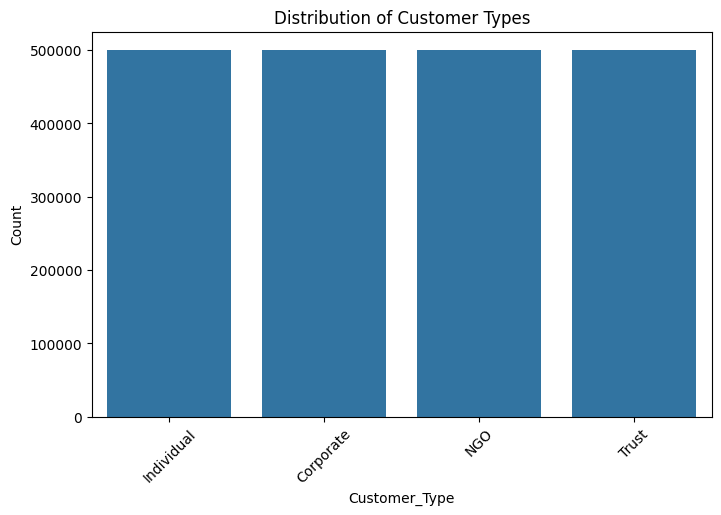

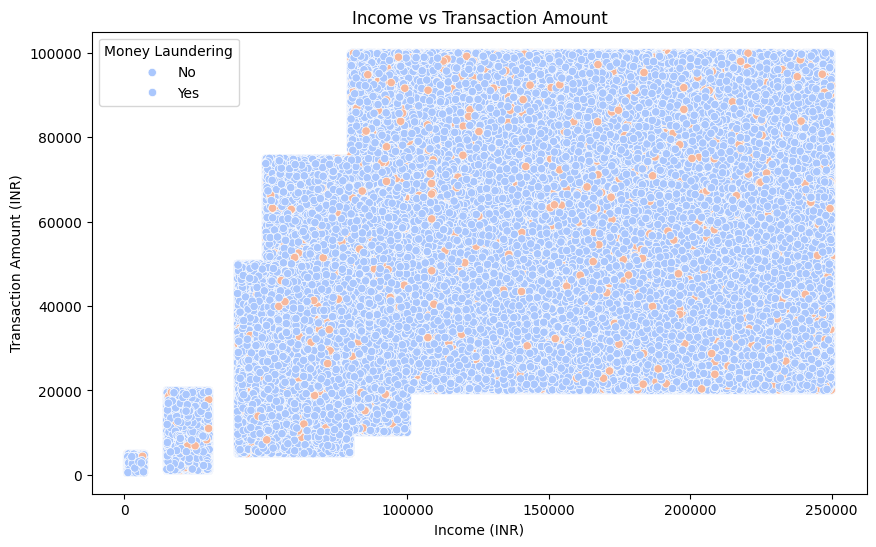

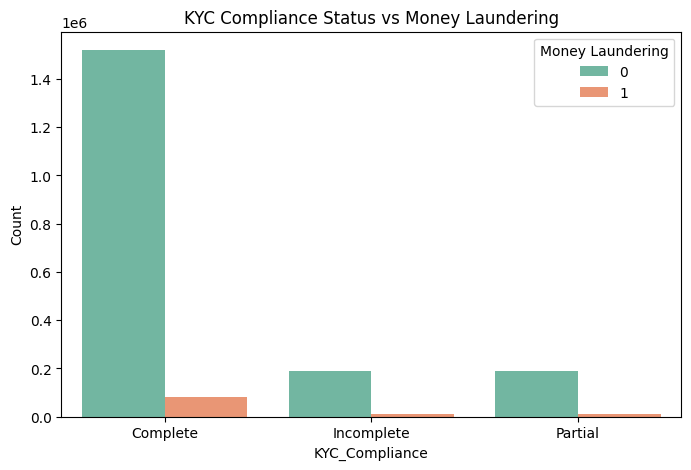

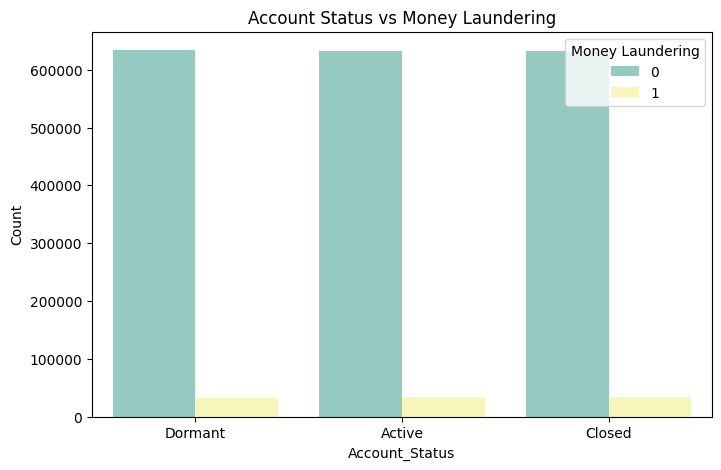

<ipython-input-2-9d1fa6b9c016>:54: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Unusual_Timing', y='Money_Laundering', ci=None, palette='husl')
<ipython-input-2-9d1fa6b9c016>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Unusual_Timing', y='Money_Laundering', ci=None, palette='husl')


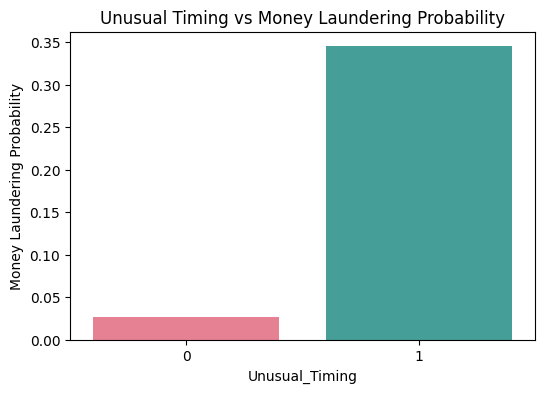


Fraudulent Records: 100000 (5.00%)

Average Risk Indicators for Fraudulent Records:
Is_High_Risk_Country      1.00000
International_Transfer    0.60149
Unusual_Timing            0.49993
Round_Amount_Flag         0.00009
dtype: float64


<ipython-input-2-9d1fa6b9c016>:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Money_Laundering'] == 1], x='Occupation', order=df['Occupation'].value_counts().index, palette='magma')


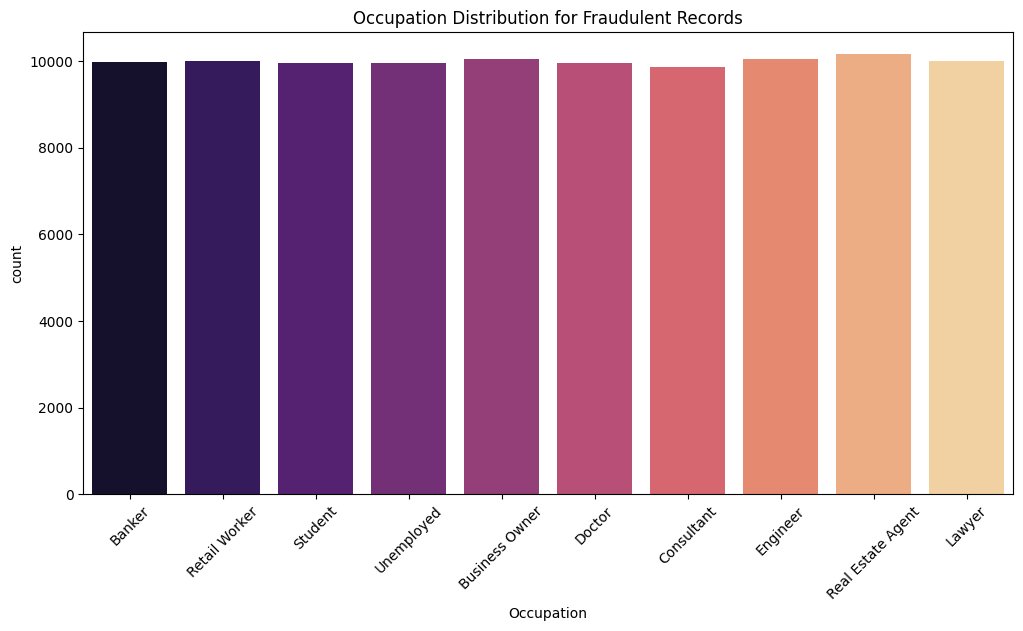


Transaction Amount Statistics:
count    2.000000e+06
mean     2.715811e+04
std      2.475023e+04
min      5.000100e+02
25%      5.458455e+03
50%      1.919408e+04
75%      4.194519e+04
max      9.999962e+04
Name: Transaction_Amount, dtype: float64

High-Risk Country Rate for Fraudulent Transactions: 100.00%

Industry Risk Distribution for Fraudulent Records:
Industry_Risk
Low       69.718
Medium    20.364
High       9.918
Name: proportion, dtype: float64

Top Features for Monitoring Potential Fraud:
['Transaction_Amount', 'Income', 'Country_Risk', 'Industry_Risk', 'KYC_Compliance', 'Is_High_Risk_Country', 'International_Transfer', 'Unusual_Timing', 'Occupation']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display settings
pd.set_option('display.max_columns', None)

# Load the dataset
df = df_rbi_pmla_improved

# === 1. Dataset Overview ===
print("Dataset Overview:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# === 2. EDA ===
# a. Customer Type Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Customer_Type', order=df['Customer_Type'].value_counts().index)
plt.title("Distribution of Customer Types")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# b. Income vs Transaction Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='Transaction_Amount', hue='Money_Laundering', palette='coolwarm')
plt.title("Income vs Transaction Amount")
plt.xlabel("Income (INR)")
plt.ylabel("Transaction Amount (INR)")
plt.legend(title="Money Laundering", labels=["No", "Yes"])
plt.show()

# c. KYC Compliance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='KYC_Compliance', hue='Money_Laundering', palette='Set2')
plt.title("KYC Compliance Status vs Money Laundering")
plt.ylabel("Count")
plt.legend(title="Money Laundering")
plt.show()

# d. Account Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Account_Status', hue='Money_Laundering', palette='Set3')
plt.title("Account Status vs Money Laundering")
plt.ylabel("Count")
plt.legend(title="Money Laundering")
plt.show()

# e. Unusual Timing
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Unusual_Timing', y='Money_Laundering', ci=None, palette='husl')
plt.title("Unusual Timing vs Money Laundering Probability")
plt.ylabel("Money Laundering Probability")
plt.show()

# === 3. Fraud Analysis ===
# a. Fraud Distribution
fraud_counts = df['Money_Laundering'].value_counts()
fraud_percentage = (fraud_counts[1] / len(df)) * 100
print(f"\nFraudulent Records: {fraud_counts[1]} ({fraud_percentage:.2f}%)")

# b. Key Risk Indicators
risk_features = ['Is_High_Risk_Country', 'International_Transfer', 'Unusual_Timing', 'Round_Amount_Flag']
risk_analysis = df[df['Money_Laundering'] == 1][risk_features].mean()
print("\nAverage Risk Indicators for Fraudulent Records:")
print(risk_analysis)

# c. Occupation Risk
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['Money_Laundering'] == 1], x='Occupation', order=df['Occupation'].value_counts().index, palette='magma')
plt.title("Occupation Distribution for Fraudulent Records")
plt.xticks(rotation=45)
plt.show()

# === 4. Statistical Insights ===
# a. Transaction Amount Stats
print("\nTransaction Amount Statistics:")
print(df['Transaction_Amount'].describe())

# b. Country Risk Analysis
high_risk_country_rate = df[df['Money_Laundering'] == 1]['Is_High_Risk_Country'].mean() * 100
print(f"\nHigh-Risk Country Rate for Fraudulent Transactions: {high_risk_country_rate:.2f}%")

# c. Industry Risk
industry_risk_distribution = df[df['Money_Laundering'] == 1]['Industry_Risk'].value_counts(normalize=True) * 100
print("\nIndustry Risk Distribution for Fraudulent Records:")
print(industry_risk_distribution)

# === 5. Recommendations and Next Steps ===
# Recommendations would be derived based on these insights. Below are the features to monitor further:
important_features = ['Transaction_Amount', 'Income', 'Country_Risk', 'Industry_Risk', 'KYC_Compliance',
                      'Is_High_Risk_Country', 'International_Transfer', 'Unusual_Timing', 'Occupation']
print("\nTop Features for Monitoring Potential Fraud:")
print(important_features)


In [ ]:
# Income-to-Transaction Ratio
df['Income_to_Transaction_Ratio'] = df['Transaction_Amount'] / (df['Income'] + 1)  # Avoid division by zero

# Transaction Per Tenure
df['Transaction_Per_Tenure'] = df['Transaction_Count'] / (df['Customer_Account_Tenure'] + 0.1)  # Avoid division by zero

# Composite Risk Score
df['Risk_Score'] = (
    df['Country_Risk'] +
    df['Is_High_Risk_Country'] +
    df['International_Transfer'] +
    df['Unusual_Timing'] +
    df['Round_Amount_Flag']
)

# Binning Income Levels
df['Income_Bin'] = pd.cut(df['Income'], bins=[0, 30000, 70000, 150000, np.inf],
                          labels=['Low', 'Medium', 'High', 'Very High'])


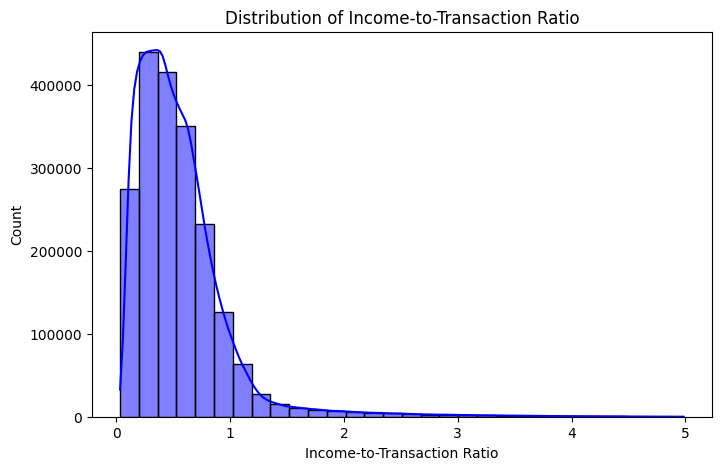

<ipython-input-4-39f702b5c809>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Money_Laundering', y='Risk_Score', palette='coolwarm')


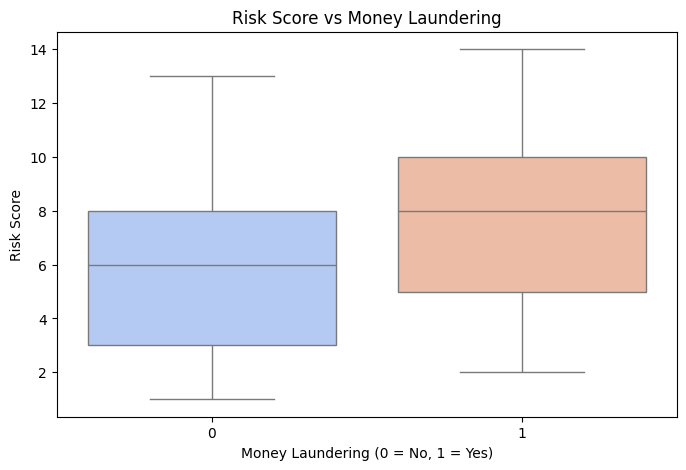

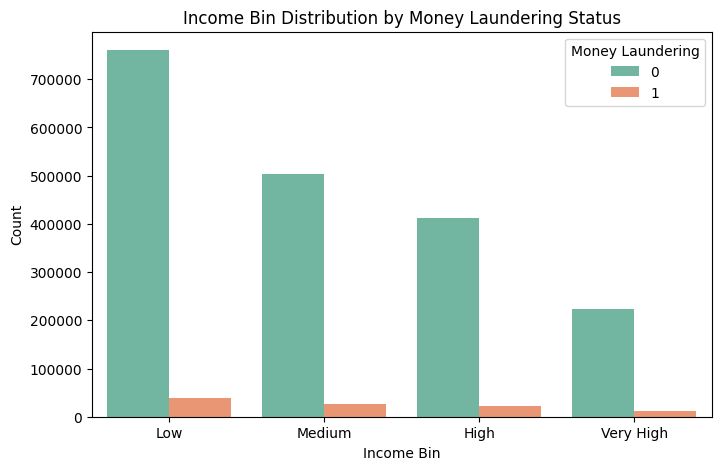

In [ ]:
# Distribution of Income-to-Transaction Ratio
plt.figure(figsize=(8, 5))
sns.histplot(df['Income_to_Transaction_Ratio'], bins=30, kde=True, color='blue')
plt.title("Distribution of Income-to-Transaction Ratio")
plt.xlabel("Income-to-Transaction Ratio")
plt.show()

# Boxplot of Risk Score vs Money Laundering
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Money_Laundering', y='Risk_Score', palette='coolwarm')
plt.title("Risk Score vs Money Laundering")
plt.xlabel("Money Laundering (0 = No, 1 = Yes)")
plt.ylabel("Risk Score")
plt.show()

# Distribution of Income Bin
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Income_Bin', hue='Money_Laundering', palette='Set2')
plt.title("Income Bin Distribution by Money Laundering Status")
plt.xlabel("Income Bin")
plt.ylabel("Count")
plt.legend(title="Money Laundering")
plt.show()


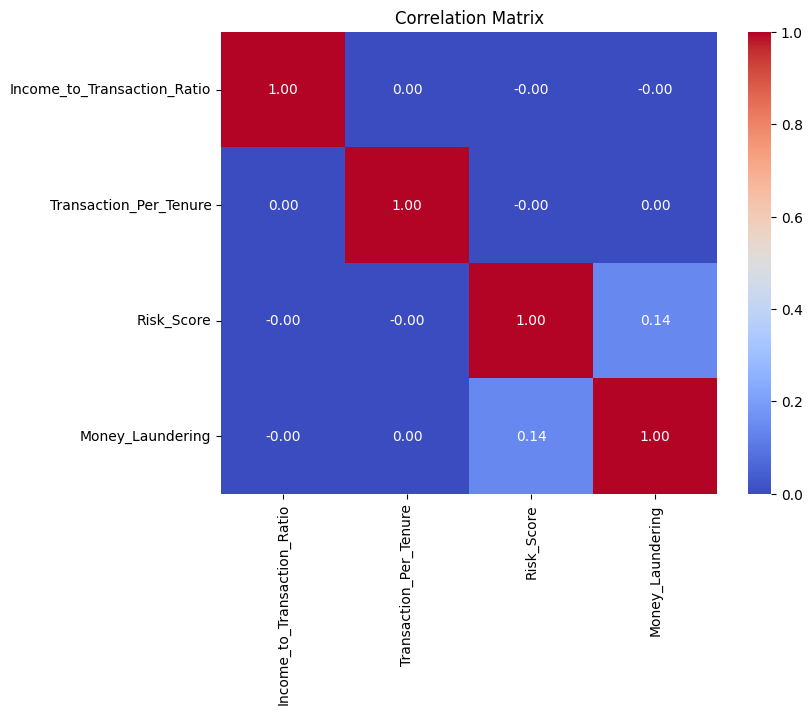

In [ ]:
# Correlation matrix
correlation_matrix = df[['Income_to_Transaction_Ratio', 'Transaction_Per_Tenure', 'Risk_Score', 'Money_Laundering']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# List of categorical columns to encode
categorical_columns = ['Customer_Type', 'Account_Status', 'KYC_Compliance', 'Industry_Risk', 'Income_Bin', 'Transaction_Type', 'Occupation']

# Apply label encoding to each categorical column
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Show the first few rows after label encoding
print(df.head())

   ID  Customer_Type  Account_Status  KYC_Compliance  Industry_Risk  \
0   1              1               2               0              1   
1   2              0               0               0              1   
2   3              3               0               0              1   
3   4              0               1               0              2   
4   5              1               0               0              1   

   Transaction_Amount  Transaction_Count  Country_Risk  Is_High_Risk_Country  \
0            41804.66                 23             1                     0   
1             2573.59                 15             9                     0   
2             2975.06                 21             2                     0   
3             1056.70                 25             2                     0   
4            47260.43                 15             4                     0   

   International_Transfer  Unusual_Timing  Round_Amount_Flag  \
0                       0   

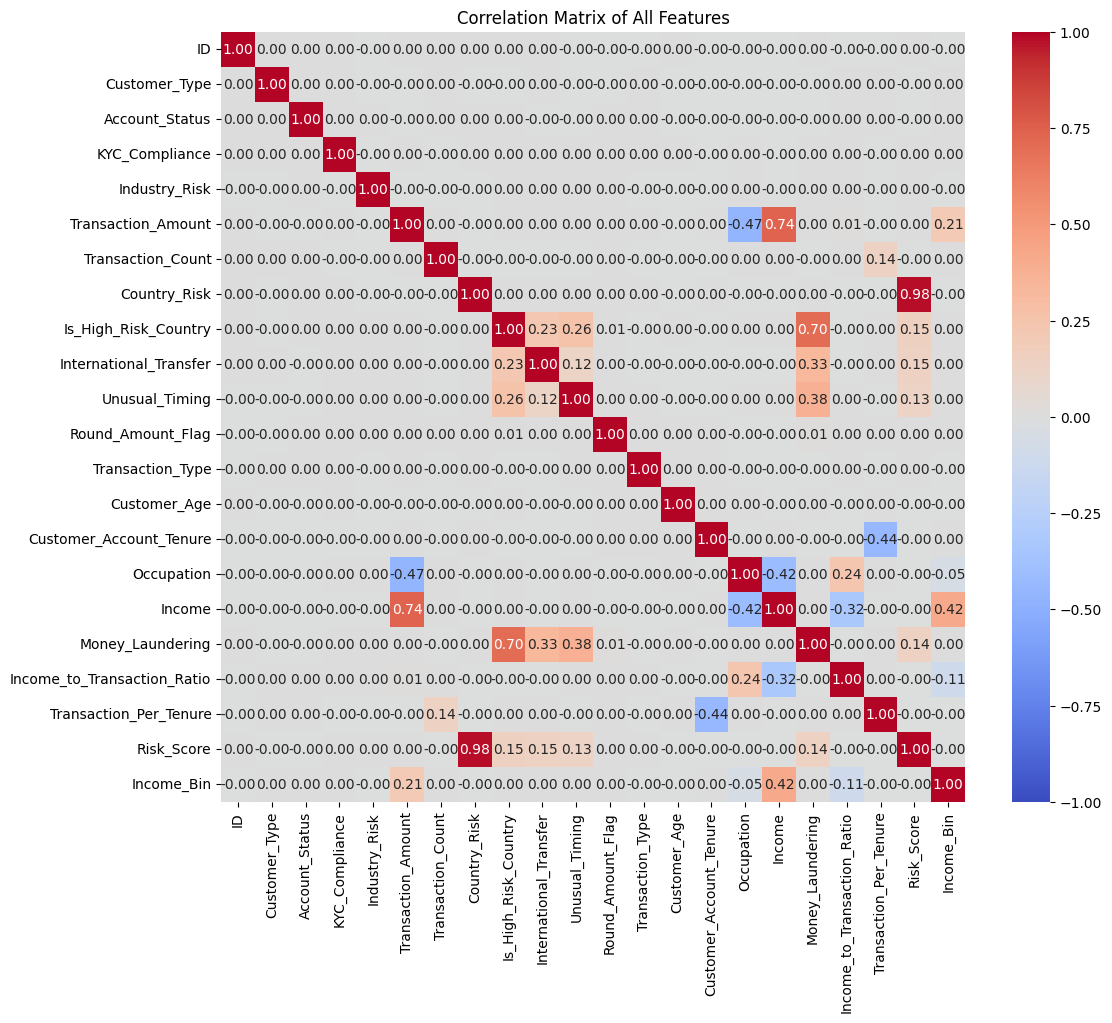

In [ ]:
# Calculate correlation matrix for all numerical features
correlation_matrix_all = df.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix of All Features")
plt.show()

In [ ]:
# Find highly correlated features (absolute correlation > 0.9)
threshold = 0.9
highly_correlated_pairs = []

for i in range(len(correlation_matrix_all.columns)):
    for j in range(i):
        if abs(correlation_matrix_all.iloc[i, j]) > threshold:
            highly_correlated_pairs.append((correlation_matrix_all.columns[i], correlation_matrix_all.columns[j]))

print("Highly Correlated Pairs (correlation > 0.9):")
for pair in highly_correlated_pairs:
    print(pair)


Highly Correlated Pairs (correlation > 0.9):
('Risk_Score', 'Country_Risk')


In [ ]:
df['Risk_Score_Country_Risk_Interaction'] = df['Risk_Score'] * df['Country_Risk']


In [ ]:
df

,ID,Customer_Type,Account_Status,KYC_Compliance,Industry_Risk,Transaction_Amount,Transaction_Count,Country_Risk,Is_High_Risk_Country,International_Transfer,Unusual_Timing,Round_Amount_Flag,Transaction_Type,Customer_Age,Customer_Account_Tenure,Occupation,Income,Money_Laundering,Income_to_Transaction_Ratio,Transaction_Per_Tenure,Risk_Score,Income_Bin,Risk_Score_Country_Risk_Interaction
0,1,1,2,0,1,41804.66,23,1,0,0,0,0,1,37,0.1,1,164809.45,0,0.253653,115.000000,1,3,1
1,2,0,0,0,1,2573.59,15,9,0,0,1,0,0,24,5.1,9,1531.85,0,1.678957,2.884615,10,1,90
2,3,3,0,0,1,2975.06,21,2,0,0,0,0,2,26,1.1,9,3774.95,0,0.787897,17.500000,2,1,4
3,4,0,1,0,2,1056.70,25,2,0,0,0,0,1,46,3.7,9,6474.07,0,0.163195,6.578947,2,1,4
4,5,1,0,0,1,47260.43,15,4,0,0,1,0,2,21,2.4,4,41745.22,0,1.132089,6.000000,5,2,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1999996,0,1,0,0,55521.72,18,1,0,1,0,0,2,22,2.1,6,209509.38,0,0.265007,8.181818,2,3,2
1999996,1999997,2,2,1,1,3086.16,22,10,0,0,0,0,1,62,0.6,8,5146.25,0,0.599575,31.428571,10,1,100
1999997,1999998,3,1,0,1,2808.11,18,10,1,0,0,0,2,33,6.5,9,6001.57,0,0.467818,2.727273,11,1,110
1999998,1999999,0,0,0,0,2215.46,19,4,0,0,0,0,1,22,0.7,2,28011.71,0,0.079088,23.750000,4,1,16


In [ ]:
# Compute the correlation matrix
corr_matrix = df.corr()

# Find pairs of features with correlation > 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j]))

print("Highly Correlated Pairs (correlation > 0.9):")
print(high_corr_pairs)


Highly Correlated Pairs (correlation > 0.9):
[('Risk_Score', 'Country_Risk'), ('Risk_Score_Country_Risk_Interaction', 'Country_Risk'), ('Risk_Score_Country_Risk_Interaction', 'Risk_Score')]


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to 'Transaction_Type' and other categorical features
df['Transaction_Type'] = label_encoder.fit_transform(df['Transaction_Type'])

# If you have other categorical columns like 'Occupation', 'Customer_Type', etc.
categorical_columns = ['Customer_Type', 'Account_Status', 'KYC_Compliance', 'Industry_Risk', 'Occupation']
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Check the updated DataFrame
print(df[['Transaction_Type', 'Customer_Type', 'Occupation']].head())


   Transaction_Type  Customer_Type  Occupation
0                 1              1           1
1                 0              0           9
2                 2              3           9
3                 1              0           9
4                 2              1           4


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Identify categorical columns (these need to be encoded)
categorical_columns = ['Transaction_Type', 'Customer_Type', 'Account_Status',
                       'KYC_Compliance', 'Industry_Risk', 'Occupation', 'Income_Bin']

# Apply Label Encoding for columns that have an ordinal relationship (if applicable)
# In your case, 'Account_Status' and 'KYC_Compliance' could be ordinal, while others are nominal

# Label Encoding for 'Customer_Type', 'Account_Status', 'KYC_Compliance', and 'Industry_Risk' (if necessary)
label_encoder = LabelEncoder()

# Loop through columns and apply LabelEncoder
for col in categorical_columns:
    # Apply encoding to the categorical columns
    if df[col].dtype == 'object':  # Only apply to columns with string data
        df[col] = label_encoder.fit_transform(df[col])

# Check if all categorical columns are now encoded
print(df[categorical_columns].head())


   Transaction_Type  Customer_Type  Account_Status  KYC_Compliance  \
0                 1              1               2               0   
1                 0              0               0               0   
2                 2              3               0               0   
3                 1              0               1               0   
4                 2              1               0               0   

   Industry_Risk  Occupation  Income_Bin  
0              1           1           3  
1              1           9           1  
2              1           9           1  
3              2           9           1  
4              1           4           2  


In [ ]:
df

,ID,Customer_Type,Account_Status,KYC_Compliance,Industry_Risk,Transaction_Amount,Transaction_Count,Country_Risk,Is_High_Risk_Country,International_Transfer,Unusual_Timing,Round_Amount_Flag,Transaction_Type,Customer_Age,Customer_Account_Tenure,Occupation,Income,Money_Laundering,Income_to_Transaction_Ratio,Transaction_Per_Tenure,Risk_Score,Income_Bin,Risk_Score_Country_Risk_Interaction
0,1,1,2,0,1,41804.66,23,1,0,0,0,0,1,37,0.1,1,164809.45,0,0.253653,115.000000,1,3,1
1,2,0,0,0,1,2573.59,15,9,0,0,1,0,0,24,5.1,9,1531.85,0,1.678957,2.884615,10,1,90
2,3,3,0,0,1,2975.06,21,2,0,0,0,0,2,26,1.1,9,3774.95,0,0.787897,17.500000,2,1,4
3,4,0,1,0,2,1056.70,25,2,0,0,0,0,1,46,3.7,9,6474.07,0,0.163195,6.578947,2,1,4
4,5,1,0,0,1,47260.43,15,4,0,0,1,0,2,21,2.4,4,41745.22,0,1.132089,6.000000,5,2,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1999996,0,1,0,0,55521.72,18,1,0,1,0,0,2,22,2.1,6,209509.38,0,0.265007,8.181818,2,3,2
1999996,1999997,2,2,1,1,3086.16,22,10,0,0,0,0,1,62,0.6,8,5146.25,0,0.599575,31.428571,10,1,100
1999997,1999998,3,1,0,1,2808.11,18,10,1,0,0,0,2,33,6.5,9,6001.57,0,0.467818,2.727273,11,1,110
1999998,1999999,0,0,0,0,2215.46,19,4,0,0,0,0,1,22,0.7,2,28011.71,0,0.079088,23.750000,4,1,16


In [ ]:
df = df.drop('ID', axis=1)

In [ ]:
df = df.drop('Country_Risk', axis=1)

In [ ]:
df = df.drop('Risk_Score', axis=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9808 - loss: 0.0508 - val_accuracy: 0.9834 - val_loss: 0.0426
Epoch 2/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - accuracy: 0.9832 - loss: 0.0427 - val_accuracy: 0.9834 - val_loss: 0.0425
Epoch 3/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - accuracy: 0.9831 - loss: 0.0433 - val_accuracy: 0.9833 - val_loss: 0.0427
Epoch 4/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 72s 2ms/step - accuracy: 0.9832 - loss: 0.0427 - val_accuracy: 0.9834 - val_loss: 0.0425
Epoch 5/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9831 - loss: 0.0425 - val_accuracy: 0.9834 - val_loss: 0.0425
Epoch 6/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - accuracy: 0.9833 - loss: 0.0427 - val_accuracy: 0.9834 - val_loss: 0.0425
Epoch 7/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - accuracy: 0.9833 - loss: 0.0427 - val_accuracy: 0.9834 - val_loss: 0.0426
Epoch 8/10
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 93s 3ms/step - accuracy: 

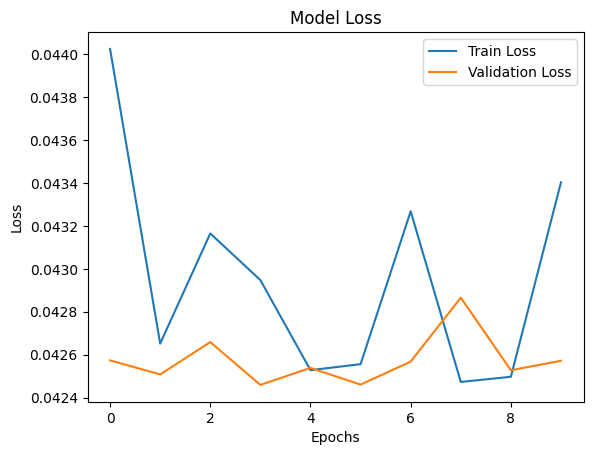

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# Features and target
X = df.drop(columns=['Money_Laundering'])  # Drop ID and target column
y = df['Money_Laundering']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the Neural Network model using Keras (TensorFlow backend)
model = tf.keras.Sequential()

# Add input layer with 64 neurons (input size matches the number of features)
model.add(tf.keras.layers.Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))

# Add hidden layers
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(16, activation='relu'))

# Output layer for binary classification (fraud or non-fraud)
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=64, validation_data=(X_test_scaled, y_test))

# Predict on the test set
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

# Evaluate the model performance
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Calculate AUC-ROC score
y_pred_prob = model.predict(X_test_scaled)  # Get probability for fraud class (1)
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nAUC-ROC: {roc_auc:.4f}")

# Optionally: Plot the training and validation loss to check for overfitting/underfitting
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()